## A notebook for testing the seir equations with a forward Euler and a Monte Carlo model.

In [314]:
import time
import pandas as pd
import numpy as np
from IPython.display import HTML
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.animation import FuncAnimation

import monte_carlo.seir_monte_carlo as mc
import forward_euler.seir_forward_euler as f

### Input Parameters

In [315]:
seir_labels = ["Susceptible", "Exposed", "Infected", "Recovered"]

shared_parameters = {
    "s_0": 0.333,
    "e_0": 0.333,
    "i_0": 0.333,
    "r_0": 0.001,
    "beta": 1.0,
    "sigma": 0.1,
    "gamma": 0.005
}

# Forward Euler parameters
step = 0.1
t_final = 300
f_euler_output = "f_euler_seir_data.csv"

# Monte Carlo parameters
length = 100
agent_count = 250
MCS = 2000
mc_seir_output = "mc_seir_data.csv"
mc_lattice_output = "mc_lattice_data.csv"

## Forward Euler simulation

In [316]:
try:
    start = time.perf_counter()
    f.forward_euler(**shared_parameters, step=step, t_final=t_final, seir_filename=f_euler_output) # Calling the Pybinded C++ function
    end = time.perf_counter()
    print(f"Time elapse = {(end - start):.4f} seconds")
    f_euler_df = pd.read_csv(f_euler_output)
except ValueError as e:
    print(f"Error: {e}")

Time elapse = 0.0027 seconds


### Line plot

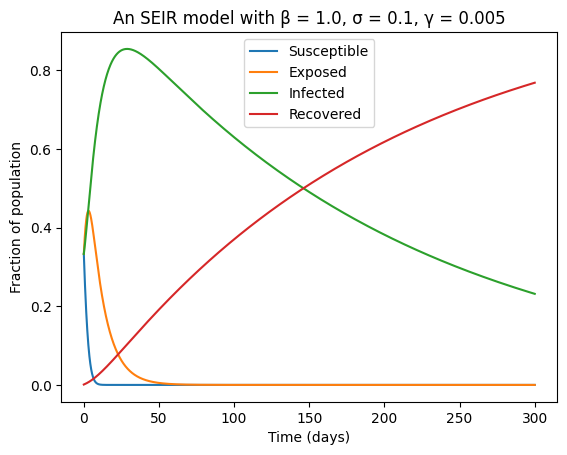

In [ ]:
%matplotlib inline
fig, ax = plt.subplots()

for label in seir_labels:
    ax.plot(f_euler_df.iloc[:,0], f_euler_df[label.lower()], label=label) # Plotting each population category on the same ax

ax.set_title(f"An SEIR model with β = {shared_parameters['beta']}, σ = {shared_parameters['sigma']}, γ = {shared_parameters['gamma']}")
ax.set_ylabel("Fraction of population")
ax.set_xlabel("Time (days)")
ax.legend(frameon=True)

# plt.savefig("fig1a.svg")
plt.show()

### Population Tests

In [318]:
final_population = 0
for label in seir_labels:
    value = f_euler_df[label.lower()].iloc[-1]
    final_population += value
    print(f"The final {label} value is: {value}")
print(f"\nThe final population of the simulation is: {final_population}")


The final Susceptible value is: 1.12104e-44
The final Exposed value is: 6.1841e-14
The final Infected value is: 0.231607
The final Recovered value is: 0.768392

The final population of the simulation is: 0.9999990000000618


## Monte Carlo simulation

In [319]:
try:
    sim = mc.System(**shared_parameters, length=length, agent_count=agent_count) # Initialising simulation system
    sim.run_sim(MCS=MCS, seir_filename=mc_seir_output, lattice_filename=mc_lattice_output) # Running sim

    mc_seir_df = pd.read_csv(mc_seir_output)
    mc_lattice_df = pd.read_csv(mc_lattice_output)
except ValueError as e:
    print(f"Error: {e}")

### Line plot

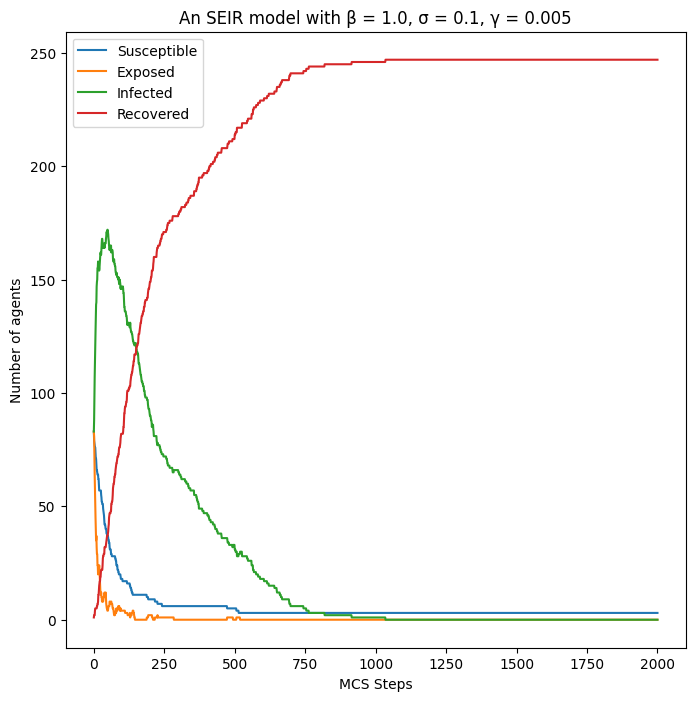

In [ ]:
%matplotlib inline
fig, ax = plt.subplots()
fig.set_size_inches(8,8)

for label in seir_labels:
    ax.plot(mc_seir_df.iloc[:,0], mc_seir_df[label.lower()], label=label) # Plotting the same as for the forward Euler data

ax.set_xlabel("MCS Steps")
ax.set_ylabel("Number of agents")
ax.legend(frameon=True)
ax.set_title(f"An SEIR model with β = {shared_parameters['beta']}, σ = {shared_parameters['sigma']}, γ = {shared_parameters['gamma']}")

# plt.savefig("fig2a.svg")
plt.show()

### Population Tests

In [321]:
final_population = 0
for label in seir_labels:
    value = mc_seir_df[label.lower()].iloc[-1]
    final_population += value
    print(f"The final {label} population is: {value}")
print(f"\nThe final total population of the simulation is: {final_population}")

The final Susceptible population is: 3
The final Exposed population is: 0
The final Infected population is: 0
The final Recovered population is: 247

The final total population of the simulation is: 250


### Lattice plot

In [ ]:
%matplotlib inline
# ^ Allows the output to appear in the cell

lattices_1d = mc_lattice_df.iloc[:, 1].to_list() # Extracting the lattices
lattices_2d = []

for l in lattices_1d:
    temp = np.array(l.split(), dtype=int) 
    l_2d = np.reshape(temp, (length, length))
    lattices_2d.append(l_2d) # Taking the lattice strings, turning them into arrays with entry per cell and then reshaping into a grid

fig, ax = plt.subplots(figsize=(7,5), dpi=100) # The dpi is quite high as when it was tested lower, the pixels on the plot didn't all appear the same size.

plot_colors = ['white', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red'] # tab: sets the colours to be the default matplotlib colours, as in the previous 2 plots

cmap = colors.ListedColormap(plot_colors)
norm = colors.NoNorm() # Mapping the colours to the entries. No norm means they'll map in ascending order, e.g. 0 -> white, 1 -> blue etc...

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.set_ylim(0, length)

image = ax.imshow(lattices_2d[0], cmap=cmap, norm=norm, animated=True, extent=[0, length, length, 0]) # Creating the initial image to update with FuncAnimation

patches = [mpatches.Patch(color=plot_colors[j+1], label=(seir_labels[j])) for j in range(4)] # A custom legend since the current labels would be 1, 2, 3..., this maps each label to a color.
ax.legend(handles=patches, loc=1, bbox_to_anchor=(1., 0.6), frameon=True) # Plotting the custom patches

plt.tight_layout()  

def update(frame):
    image.set_data(lattices_2d[frame])
    return [image] # Returning a list for the blitting. This enables the animation to only update parts of the plot that've changed.

animation = FuncAnimation(
    fig,
    update,
    frames=20,
    interval=10, # The delay between frames
    blit=True # Telling the animation to only update what's changed in the image, not to recreate it each time
)

plt.rcParams['animation.embed_limit'] = 100.0
html = HTML(animation.to_jshtml()) # Animation takes a minute to load.

# plt.savefig("reference_lattice.svg")
plt.close(fig)

display(html)

### Lattice Tests

In [323]:
passed = True
blank_count = lattices_1d[0].count('0')

for l in lattices_1d[1:]:
    if l.count('0') != 2:
        print("The number of blank tiles is not constant throughout the simulation.")
        passed = False
        break

if passed:
    print("The number of blank tiles is constant throughout the simulation.")    


The number of blank tiles is not constant throughout the simulation.
